* Importing the libraries

In [ ]:
# Import the required libraries
import numpy as np
from google.colab import drive

* Importing the data

In [ ]:
# Mount Google Drive to the Colab environment
drive.mount('/content/drive')

# Define the folder path where the dataset is located in your Google Drive
# IMPORTANT: You must change the path below to match where you saved the files
folder_path = '/content/drive/MyDrive/Colab Notebooks/Neural Networks/RNN/Coffee Machine Consumption/'

# Load the dataset files using numpy's loadtxt function
# This converts the text files into numpy arrays
input_data = np.loadtxt(folder_path + 'Input_Data.txt', delimiter=',')
output_data = np.loadtxt(folder_path + 'Output_Data.txt', delimiter=',')

# Load the single values for maximum aggregated and appliance consumption
max_agg = np.loadtxt(folder_path + 'CoffeeMachinemaxAgg.txt')
max_app = np.loadtxt(folder_path + 'CoffeeMachinemaxApp.txt')

# Print the shapes and values to verify everything loaded correctly
print("Input Data Shape:", input_data.shape)
print("Output Data Shape:", output_data.shape)
print("Max Aggregated Consumption:", max_agg)
print("Max Appliance Consumption:", max_app)

Mounted at /content/drive
Input Data Shape: (50000, 40)
Output Data Shape: (50000, 40)
Max Aggregated Consumption: 1633.7
Max Appliance Consumption: 1085.09375


* Plot drawing

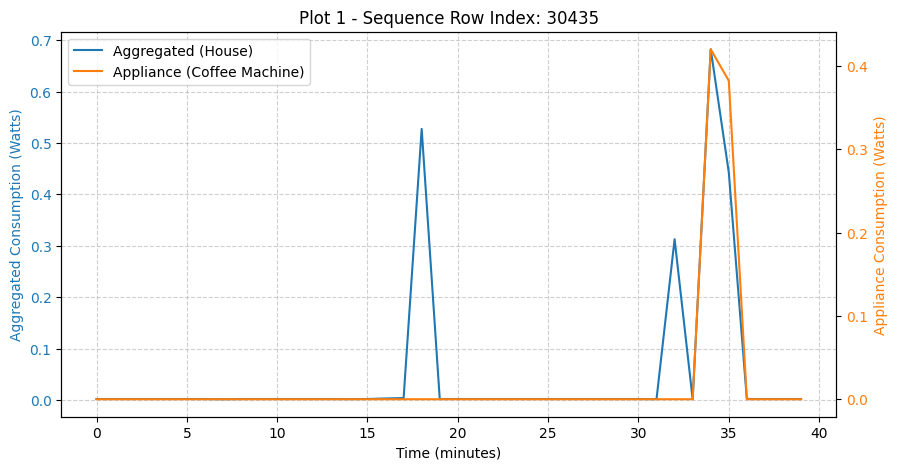

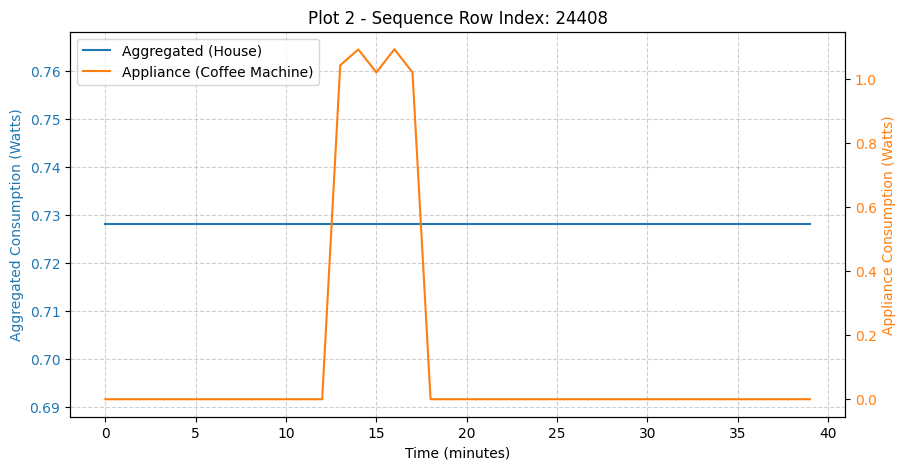

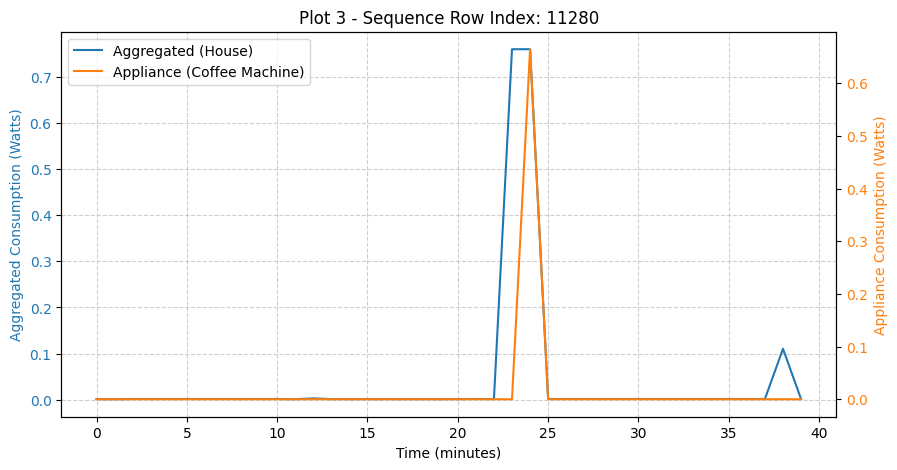

In [ ]:
import matplotlib.pyplot as plt
import random

# Total number of sequences (rows) in our data
total_sequences = input_data.shape[0]

# Rule: At least one plot must show the appliance turned on.
# We find all rows where the sum of the appliance consumption is greater than 0
active_appliance_indices = np.where(np.sum(output_data, axis=1) > 0)[0]

# 1. Pick one random index from the active ones
idx1 = random.choice(active_appliance_indices)
# 2. Pick two completely random indices for the other plots
idx2 = random.randint(0, total_sequences - 1)
idx3 = random.randint(0, total_sequences - 1)

# List of the 3 chosen sequences to plot
random_indices = [idx1, idx2, idx3]

# Loop to create 3 plots
for i, idx in enumerate(random_indices):
    # Create a figure and a primary axis
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # --- Primary Y-Axis (Aggregated Consumption) ---
    color_agg = 'tab:blue'
    ax1.set_xlabel('Time (minutes)')
    ax1.set_ylabel('Aggregated Consumption (Watts)', color=color_agg)
    # Plot the input sequence on ax1
    line1 = ax1.plot(input_data[idx], color=color_agg, label='Aggregated (House)')
    ax1.tick_params(axis='y', labelcolor=color_agg)

    # --- Secondary Y-Axis (Appliance Consumption) ---
    # Create a twin axis sharing the same X-axis
    ax2 = ax1.twinx()
    color_app = 'tab:orange'
    ax2.set_ylabel('Appliance Consumption (Watts)', color=color_app)
    # Plot the output sequence on ax2
    line2 = ax2.plot(output_data[idx], color=color_app, label='Appliance (Coffee Machine)')
    ax2.tick_params(axis='y', labelcolor=color_app)

    # --- Title and Legend ---
    plt.title(f'Plot {i+1} - Sequence Row Index: {idx}')

    # Combine the legends from both axes into one
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left')

    # Add a grid and display the plot
    ax1.grid(True, linestyle='--', alpha=0.6)
    plt.savefig(f'plot_{i+1}.png')
    plt.show()

* Normalization

In [ ]:
# 1. Normalization
# Divide input and output data by their respective maximum values
# This scales all values to be between 0 and 1
X_normalized = input_data / max_agg
y_normalized = output_data / max_app

* Reshaping the data

In [ ]:
# 2. Reshape the data for RNNs (Samples, Timesteps, Features)
# We add a 3rd dimension since we have 1 feature (Power) per timestep
X_normalized = np.expand_dims(X_normalized, axis=-1)
y_normalized = np.expand_dims(y_normalized, axis=-1)

* Creating the indices

In [ ]:
# 3. Create indices and shuffle them randomly
total_samples = X_normalized.shape[0]
indices = np.arange(total_samples)

# Set a random seed so we get the exact same random split every time we run the code
np.random.seed(42)
np.random.shuffle(indices)

* Train, Validation and Test sets

In [ ]:
# 4. Define split percentages: 70% Train, 15% Validation, 15% Test
train_split = int(0.7 * total_samples)
val_split = int(0.85 * total_samples) # 70% + 15% = 85%

# Generate the specific indices for each set
train_idx = indices[:train_split]
val_idx = indices[train_split:val_split]
test_idx = indices[val_split:]

* Printing the shape

In [ ]:
# 5. Create the final datasets using the indices
X_train, y_train = X_normalized[train_idx], y_normalized[train_idx]
X_val, y_val = X_normalized[val_idx], y_normalized[val_idx]
X_test, y_test = X_normalized[test_idx], y_normalized[test_idx]

# Print shapes to verify
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (35000, 40, 1), y_train shape: (35000, 40, 1)
X_val shape: (7500, 40, 1), y_val shape: (7500, 40, 1)
X_test shape: (7500, 40, 1), y_test shape: (7500, 40, 1)


* Models Architecture

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, SimpleRNN
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError

# Get sequence length and input dimensions automatically from the shape of our training data
seq_length = X_train.shape[1]
input_dim = X_train.shape[2]
output_dim = 1 # We want to predict 1 value per timestep (Appliance consumption)

* RNN model

In [ ]:
# ==========================================
# 1. Build Simple RNN Model
# ==========================================
model_rnn = Sequential(name="RNN_Model")
model_rnn.add(SimpleRNN(64, input_shape=(seq_length, input_dim), return_sequences=True))
# The Dense layer outputs the final prediction for each timestep
model_rnn.add(Dense(output_dim))
model_rnn.compile(optimizer=Adam(learning_rate=0.001), loss=MeanSquaredError())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


* LSTM model

In [ ]:
# ==========================================
# 2. Build LSTM Model
# ==========================================
model_lstm = Sequential(name="LSTM_Model")
model_lstm.add(LSTM(64, input_shape=(seq_length, input_dim), return_sequences=True))
model_lstm.add(Dense(output_dim))
model_lstm.compile(optimizer=Adam(learning_rate=0.001), loss=MeanSquaredError())

* GRU model

In [ ]:
# ==========================================
# 3. Build GRU Model
# ==========================================
model_gru = Sequential(name="GRU_Model")
model_gru.add(GRU(64, input_shape=(seq_length, input_dim), return_sequences=True))
model_gru.add(Dense(output_dim))
model_gru.compile(optimizer=Adam(learning_rate=0.001), loss=MeanSquaredError())

* Summaries of the models

In [ ]:
# Print summaries to see the architecture details
print("--- RNN Summary ---")
model_rnn.summary()
print("\n--- LSTM Summary ---")
model_lstm.summary()
print("\n--- GRU Summary ---")
model_gru.summary()

--- RNN Summary ---


Model: "RNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 40, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 40, 1)          │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

...

Model: "GRU_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 40, 64)         │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 40, 1)          │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 0 (0.00 B)

* Training

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Define Early Stopping callback
# monitor='val_loss': We watch the validation error
# patience=5: Stop if it doesn't improve for 5 epochs
# start_from_epoch=30: Wait until epoch 30 before starting to monitor (Satisfies the >= 30 epochs rule)
# restore_best_weights=True: When it stops, keep the weights of the best epoch, not the last one
early_stop = EarlyStopping(monitor='val_loss', patience=5, start_from_epoch=30, restore_best_weights=True)

# Set the maximum number of epochs and the batch size
max_epochs = 100
batch_size = 64

* RNN Training

In [ ]:
# ==========================================
# 1. Train Simple RNN
# ==========================================
print("Training Simple RNN Model...")
history_rnn = model_rnn.fit(
    X_train, y_train,
    epochs=max_epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

Training Simple RNN Model...
Epoch 1/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 1.3442e-06 - val_loss: 3.4523e-08
Epoch 2/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 3.7923e-08 - val_loss: 3.9585e-08
Epoch 3/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 4.2583e-08 - val_loss: 4.3510e-08
Epoch 4/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5.5303e-08 - val_loss: 5.5025e-08
Epoch 5/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 6.5656e-08 - val_loss: 2.9369e-08
Epoch 6/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5.6718e-08 - val_loss: 2.8965e-08
Epoch 7/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 5.5232e-08 - val_loss: 1.1641e-07
Epoch 8/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 5.9017e-08 - val_loss: 8.5454e-08
Epoch 9/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 5.5560e-08 - val_loss: 3.7441e-08
Epoch 10/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5.6444e-08 - val_loss: 3.3487e-08
Epoch 11/100
547/547

* LSTM Training

In [ ]:
# ==========================================
# 2. Train LSTM
# ==========================================
print("\nTraining LSTM Model...")
history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=max_epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)


Training LSTM Model...
Epoch 1/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 4.9123e-07 - val_loss: 3.4851e-08
Epoch 2/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 3.4717e-08 - val_loss: 3.9766e-08
Epoch 3/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 3.4782e-08 - val_loss: 3.0385e-08
Epoch 4/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 4.2352e-08 - val_loss: 3.0541e-08
Epoch 5/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 4.0995e-08 - val_loss: 2.9240e-08
Epoch 6/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 4.2707e-08 - val_loss: 3.6885e-08
Epoch 7/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 4.1937e-08 - val_loss: 2.8747e-08
Epoch 8/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 4.2957e-08 - val_loss: 8.0297e-08
Epoch 9/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 4.8107e-08 - val_loss: 1.5654e-07
Epoch 10/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 4.2190e-08 - val_loss: 2.9984e-08
Epoch 11/100
547/547 ━━━━

* GRU Training

In [ ]:
# ==========================================
# 3. Train GRU
# ==========================================
print("\nTraining GRU Model...")
history_gru = model_gru.fit(
    X_train, y_train,
    epochs=max_epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)


Training GRU Model...
Epoch 1/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 1.1974e-06 - val_loss: 3.9831e-08
Epoch 2/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 3.9428e-08 - val_loss: 3.4591e-08
Epoch 3/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 3.7557e-08 - val_loss: 3.2010e-08
Epoch 4/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 4.2156e-08 - val_loss: 1.0205e-07
Epoch 5/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 5.9556e-08 - val_loss: 4.4786e-08
Epoch 6/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 6.3080e-08 - val_loss: 8.4807e-08
Epoch 7/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 6.1802e-08 - val_loss: 2.8351e-08
Epoch 8/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 5.7729e-08 - val_loss: 1.0919e-07
Epoch 9/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 4.8062e-08 - val_loss: 3.9692e-08
Epoch 10/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 4.6169e-08 - val_loss: 2.8838e-08
Epoch 11/100
547/547 ━━━━━

* Plot drawing


--- Simple RNN Final Losses ---
Training Loss: 0.000000
Validation Loss: 0.000000


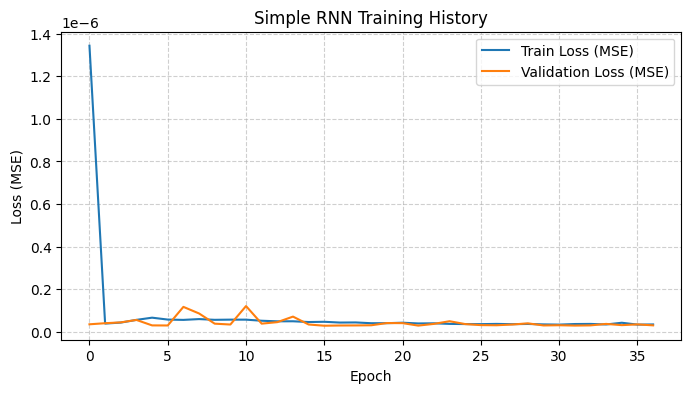


--- LSTM Final Losses ---
Training Loss: 0.000000
Validation Loss: 0.000000


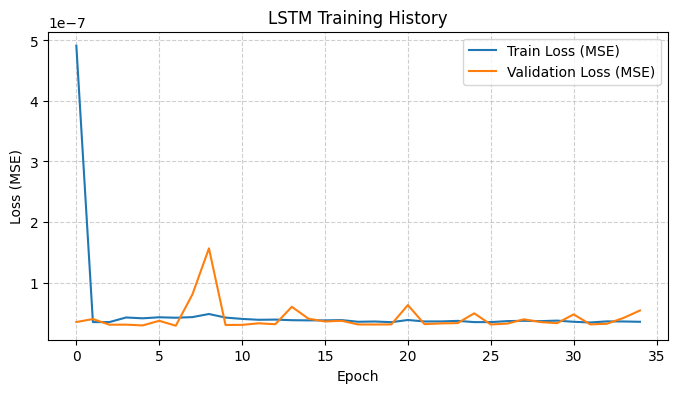


--- GRU Final Losses ---
Training Loss: 0.000000
Validation Loss: 0.000000


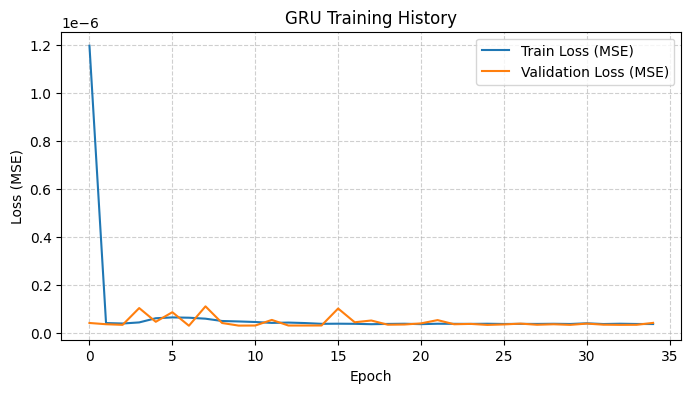

In [ ]:
# ==========================================
# Print and Plot the Losses (Requirement 6d)
# ==========================================
def plot_history(history, model_name):
    train_loss = history.history['loss']
    val_loss = history.history['val_loss']

    # Print final losses
    print(f"\n--- {model_name} Final Losses ---")
    print(f"Training Loss: {train_loss[-1]:.6f}")
    print(f"Validation Loss: {val_loss[-1]:.6f}")

    # Plot losses
    plt.figure(figsize=(8, 4))
    plt.plot(train_loss, label='Train Loss (MSE)')
    plt.plot(val_loss, label='Validation Loss (MSE)')
    plt.title(f'{model_name} Training History')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.savefig(f'{model_name}_training_history.png')
    plt.show()

# Call the plot function for each model
plot_history(history_rnn, "Simple RNN")
plot_history(history_lstm, "LSTM")
plot_history(history_gru, "GRU")

* Predictions

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, max_error

# ==========================================
# 1. Generate Predictions for Train and Test sets
# ==========================================
print("Making predictions...")
# We use one model for train predictions as per instructions (let's use LSTM as representative)
train_pred_lstm = model_lstm.predict(X_train)

# Predict on test set for all three models to compare them
test_pred_rnn = model_rnn.predict(X_test)
test_pred_lstm = model_lstm.predict(X_test)
test_pred_gru = model_gru.predict(X_test)

Making predictions...
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


* Denormalization

In [ ]:
# ==========================================
# 2. Denormalization (Multiply by max_app)
# ==========================================
# We remove the last dimension using np.squeeze so shape goes from (samples, seq_length, 1) to (samples, seq_length)
y_test_denorm = np.squeeze(y_test) * max_app
test_pred_rnn_denorm = np.squeeze(test_pred_rnn) * max_app
test_pred_lstm_denorm = np.squeeze(test_pred_lstm) * max_app
test_pred_gru_denorm = np.squeeze(test_pred_gru) * max_app

* Metrics function

In [ ]:
# ==========================================
# 3. Calculate metrics per sequence (Row-wise)
# ==========================================
n_test_sequences = y_test_denorm.shape[0]

def calculate_sequence_metrics(y_true, y_pred):
    """Calculates RMSE, MAE, and Max Error for each sequence individually."""
    # Calculate errors per sequence (axis=1 means across the time steps of each sequence)
    # Mean Squared Error first, then square root for RMSE
    rmse = np.sqrt(np.mean((y_true - y_pred)**2, axis=1))
    mae = np.mean(np.abs(y_true - y_pred), axis=1)
    max_err = np.max(np.abs(y_true - y_pred), axis=1)
    return rmse, mae, max_err

* Metrics of all 3 models

In [ ]:
# Get the 3 metrics (arrays of length n) for all 3 models
rmse_rnn, mae_rnn, max_rnn = calculate_sequence_metrics(y_test_denorm, test_pred_rnn_denorm)
rmse_lstm, mae_lstm, max_lstm = calculate_sequence_metrics(y_test_denorm, test_pred_lstm_denorm)
rmse_gru, mae_gru, max_gru = calculate_sequence_metrics(y_test_denorm, test_pred_gru_denorm)

* RMSE metric

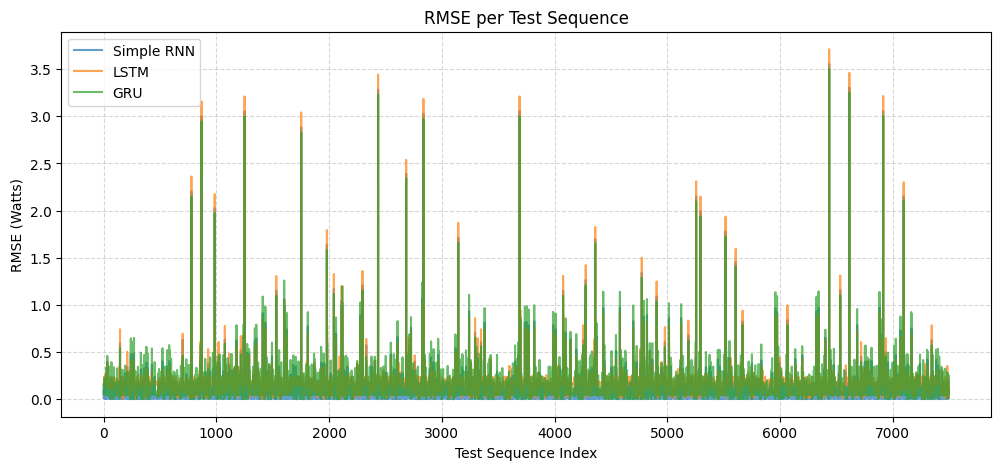

In [ ]:
# ==========================================
# 4. Plot the results (1 plot per error type)
# ==========================================
x_axis = np.arange(n_test_sequences) # From 0 to n-1

# Plot 1: RMSE
plt.figure(figsize=(12, 5))
plt.plot(x_axis, rmse_rnn, label='Simple RNN', alpha=0.7)
plt.plot(x_axis, rmse_lstm, label='LSTM', alpha=0.7)
plt.plot(x_axis, rmse_gru, label='GRU', alpha=0.7)
plt.title('RMSE per Test Sequence')
plt.xlabel('Test Sequence Index')
plt.ylabel('RMSE (Watts)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('rmse_per_sequence.png')
plt.show()

* MAE metric

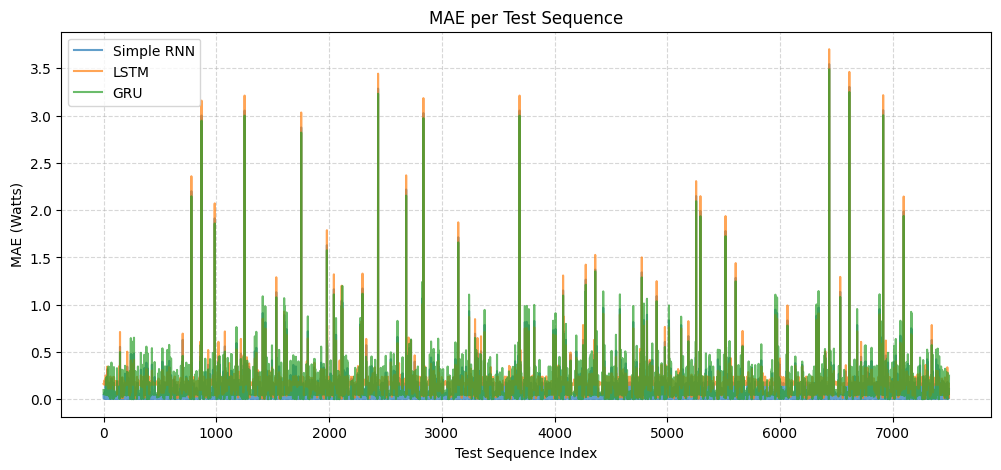

In [ ]:
# Plot 2: MAE
plt.figure(figsize=(12, 5))
plt.plot(x_axis, mae_rnn, label='Simple RNN', alpha=0.7)
plt.plot(x_axis, mae_lstm, label='LSTM', alpha=0.7)
plt.plot(x_axis, mae_gru, label='GRU', alpha=0.7)
plt.title('MAE per Test Sequence')
plt.xlabel('Test Sequence Index')
plt.ylabel('MAE (Watts)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('mae_per_sequence.png')
plt.show()

* Max Error

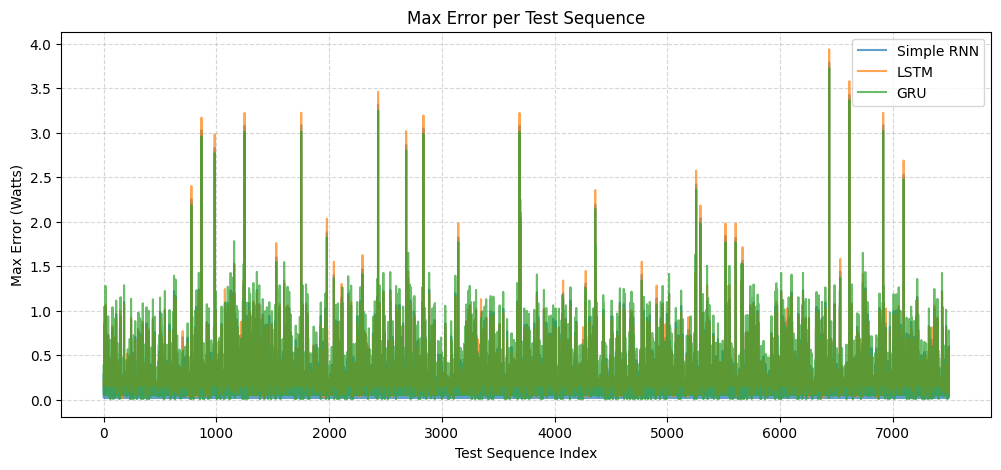

In [ ]:
# Plot 3: Max Error
plt.figure(figsize=(12, 5))
plt.plot(x_axis, max_rnn, label='Simple RNN', alpha=0.7)
plt.plot(x_axis, max_lstm, label='LSTM', alpha=0.7)
plt.plot(x_axis, max_gru, label='GRU', alpha=0.7)
plt.title('Max Error per Test Sequence')
plt.xlabel('Test Sequence Index')
plt.ylabel('Max Error (Watts)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('max_error_per_sequence.png')
plt.show()

* ON & OFF sequences

In [ ]:
# ==========================================
# 1. Identify ON and OFF sequences in the Test Set
# ==========================================
# Sum the actual consumption for each sequence
sequence_sums = np.sum(y_test_denorm, axis=1)

# Find the indices where the appliance was ON (sum > 0) and OFF (sum == 0)
# We use a very small threshold (e.g., 1e-5) for OFF just in case of floating point inaccuracies
on_indices = np.where(sequence_sums > 1e-5)[0]
off_indices = np.where(sequence_sums <= 1e-5)[0]

* Step 8

In [ ]:
# ==========================================
# 2. Select 4 sequences (2 ON, 2 OFF)
# ==========================================
# Set random seed to get the same 4 plots every time you run this cell
random.seed(42)

# Select 2 random indices from the ON list and 2 from the OFF list
selected_on = random.sample(list(on_indices), 2)
selected_off = random.sample(list(off_indices), 2)

# Combine them into a single list
selected_indices = selected_on + selected_off
status_labels = ["Appliance ON", "Appliance ON", "Appliance OFF", "Appliance OFF"]

* 4 Separate plots

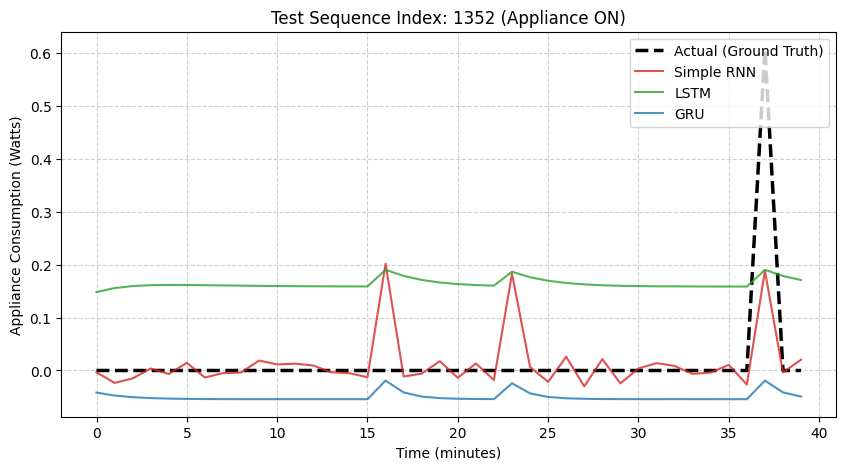

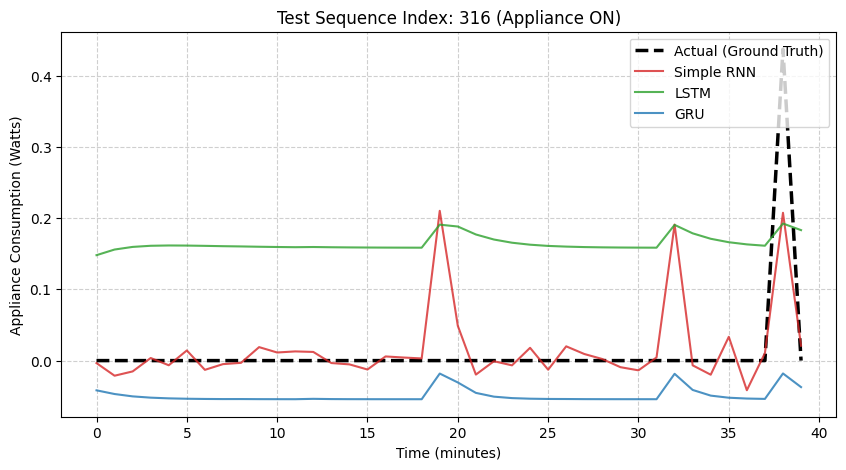

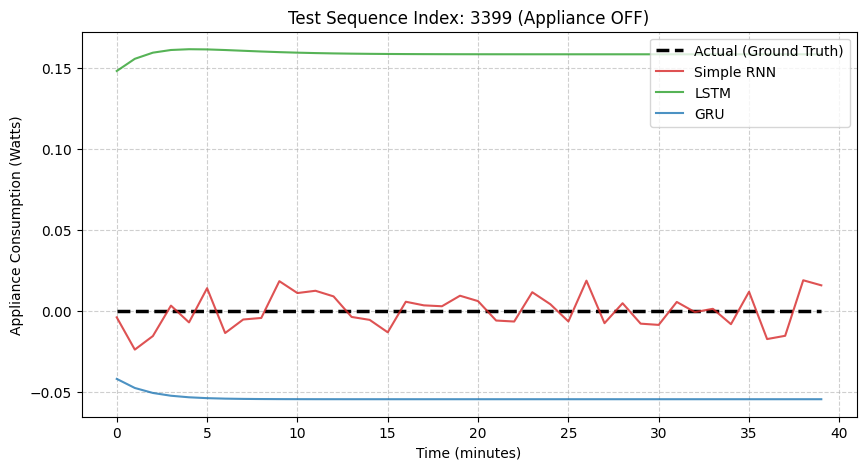

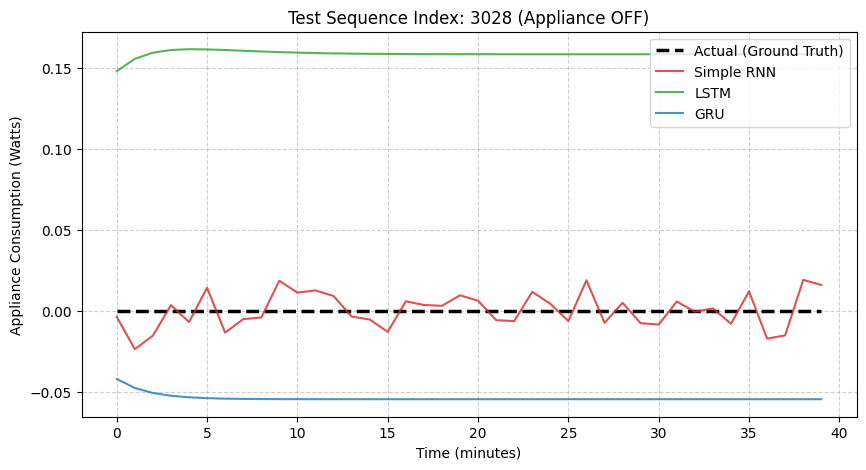

In [ ]:
# ==========================================
# 3. Create 4 separate plots
# ==========================================
for i, idx in enumerate(selected_indices):
    plt.figure(figsize=(10, 5))

    # Plot Ground Truth (Actual Consumption) as a bold dashed line
    plt.plot(y_test_denorm[idx], label='Actual (Ground Truth)', color='black', linewidth=2.5, linestyle='--')

    # Plot Predictions from all 3 models
    plt.plot(test_pred_rnn_denorm[idx], label='Simple RNN', alpha=0.8, color='tab:red')
    plt.plot(test_pred_lstm_denorm[idx], label='LSTM', alpha=0.8, color='tab:green')
    plt.plot(test_pred_gru_denorm[idx], label='GRU', alpha=0.8, color='tab:blue')

    # Add title, labels, legend, and grid
    plt.title(f'Test Sequence Index: {idx} ({status_labels[i]})')
    plt.xlabel('Time (minutes)')
    plt.ylabel('Appliance Consumption (Watts)')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)

    # Show the plot
    plt.savefig(f'test_sequence_{idx}.png')
    plt.show()